# DJ circuit slowly building up. 

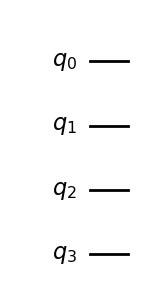

In [47]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import aer_simulator
from IPython.display import Math, display

import numpy as np 
n =3 
f0allx = QuantumCircuit(n+1) # constant oracle for f(x) = 0 for all x
# so nothing will happen to the qubits 
f0allx.draw('mpl')





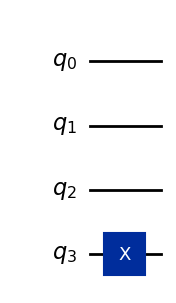

In [48]:
n=3 
f1allx = QuantumCircuit(n+1) # constant oracle for f(x) = 1 for all x
# that means we should get - at the output for all qubits. 
f1allx.x(n)
f1allx.draw('mpl')



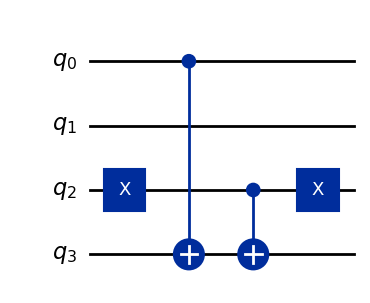

In [49]:
n=3
f01half = QuantumCircuit (n+1) # balanced oracle for f(x) = 0 for half of the inputs and f(x) = 1 for the other half
# we will use the CNOT gate to implement this.
xgates = "001"
cxgates = "101"
# Apparently it does not depend on the xgates because it undoes it before the oracle circuit ends. 
# Changing cxgats decides whether it is balanced or constant.
# Alternate bits make it balanced otherwise constant.

# Place X-gates before implenting CX in the next loop 
for i in range(n): 
    if xgates[i] == "1":
        f01half.x(i)

# place CX-gates to give phase at desired combinations
for m in range(n): 
    if cxgates[m] == "1": 
        f01half.cx(m,n)

# place X-gates after implementing CX in the previous loop
for k in range(n): 
    if xgates[k] == "1": 
        f01half.x(k)    



f01half.draw('mpl')

# add truth tables of all functions. 

# building from Deutsch algo for 2 qubits. 

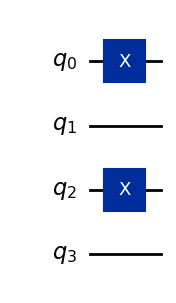

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [50]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import math


# Function to create an oracle based on the provided case
def createOracle(case):
    oracle = QuantumCircuit(2)  # Two qubits for the oracle
    if case == 1:
        oracle.x(0)  # X-gate on qubit 0
    elif case == 2:
        oracle.x(1)  # X-gate on qubit 1
    elif case == 3:
        oracle.cx(0, 1)  # Controlled-X (CNOT) gate
    elif case == 4:
        oracle.cx(0, 1)
        oracle.x(0)  # Additional X-gate on qubit 0
    return oracle


# Function to create an input state based on a binary string
def createInput(input_string):
    inputCircuit = QuantumCircuit(2)  # Two qubits for the input circuit
    for qubit, bit in enumerate(input_string):
        if bit == "1":  # Apply X-gate if the bit is 1
            inputCircuit.x(qubit)
    state = Statevector.from_instruction(inputCircuit)  # Generate the state vector
    return inputCircuit, state

# Since Deutsch's algorithm has to be hadamard in the first and last layer to work properly
def createLeadingCircuit():
    circuit = QuantumCircuit(2)
    circuit.h(0)
    circuit.h(1)
    return circuit

def createTailCircuit():
    circuit = QuantumCircuit(2)
    circuit.h(0)
    return circuit  


# Combine the leading, oracle, and tail circuits
def create_deutsch_circuit(leadingCircuit, oracle, tailCircuit):
    firstCircuit = leadingCircuit.compose(oracle)
    finalCircuit = firstCircuit.compose(tailCircuit)
    return finalCircuit


def oracle_truth_table(oracleType):
    """
    Display the truth table of the oracle in ket notation with statevectors.
    Args:
        oracleType (int): Specifies the oracle type.
    """
    # Create the oracle circuit
    oracle = createOracle(oracleType)
    
    # Iterate through all possible 2-bit inputs
    for i in range(4):  # Loop through 00, 01, 10, 11
        input_bits = format(i, "02b")  # Convert to 2-bit binary string
        inputCircuit, inputState = createInput(input_bits)
        
        # Combine the input and oracle circuits
        stitchedCircuit = inputCircuit.compose(oracle)
        statevector = Statevector.from_instruction(stitchedCircuit)
        
        # Display input in ket notation and the corresponding statevector
        display(statevector.draw('latex'))




# Run 


# Oracle type and input binary string
oracleType = 4
input_string = "11"

# Create the oracle and input circuits
main_oracle = createOracle(oracleType)
display(oracle.draw('mpl'))
inputCircuit, inputState = createInput(input_string)


qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
qc.h(1)

circuit = qc.compose(main_oracle)

qc.h(0)





oracle_truth_table(oracleType)

# DJ Algo with 3 qubits 


In [51]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector


# Function to create an oracle based on the provided case
def createOracle(case):
    oracle = QuantumCircuit(4)  # Two qubits for the oracle
    if case == 1:
        oracle.x(0)  # X-gate on qubit 0
        oracle.x(2)
    elif case == 2:
        oracle.x(1)  # X-gate on qubit 1
        oracle.x(0)
    elif case == 3:
        oracle.cx(0, 3)  # Controlled-X (CNOT) gate
        oracle.cx(2, 3)
    elif case == 4:
        for i in range(3):
            oracle.cx(i,3) 
    elif case == 5: 
        oracle.cx(0,3)
        oracle.cx(1,3)
        oracle.x(0)
        oracle.x(1)
    elif case == 6: 
        oracle.x(3)
        
    return oracle


# Function to create an input state based on a binary string
def createInput(input_string):
    inputCircuit = QuantumCircuit(4)  # Two qubits for the input circuit
    for qubit, bit in enumerate(input_string):
        if bit == "1":  # Apply X-gate if the bit is 1
            inputCircuit.x(qubit)
    state = Statevector.from_instruction(inputCircuit)  # Generate the state vector
    return inputCircuit, state

# Since Deutsch's algorithm has to be hadamard in the first and last layer to work properly
def createLeadingCircuit():
    circuit = QuantumCircuit(4)
    circuit.h(0)
    circuit.h(1)
    circuit.h(2)
    circuit.x(3)  # flip last bit to 1 for DJ algo
    circuit.h(3) 
    return circuit

def createTailCircuit():
    circuit = QuantumCircuit(4)
    circuit.h(0)
    circuit.h(1)
    circuit.h(2) 
    return circuit  


# Combine the leading, oracle, and tail circuits
def create_deutsch_circuit(leadingCircuit, oracle, tailCircuit):
    firstCircuit = leadingCircuit.compose(oracle)
    finalCircuit = firstCircuit.compose(tailCircuit)
    return finalCircuit


def oracle_truth_table(oracleType):
    """
    Display the truth table of the oracle in ket notation with statevectors.
    Args:
        oracleType (int): Specifies the oracle type.
    """
    # Create the oracle circuit
    oracle = createOracle(oracleType)
    
    # Iterate through all possible 3-bit inputs
    for i in range(8):  # Loop through 000, 010, 101, 110 and so on for 8 combinations
        input_bits = format(i, "03b")  # Convert to 3-bit binary string
        inputCircuit, inputState = createInput(input_bits)
        
        # Combine the input and oracle circuits
        stitchedCircuit = inputCircuit.compose(oracle)
        statevector = Statevector.from_instruction(stitchedCircuit)
        
        # Display input in ket notation and the corresponding statevector
        display(Math(f"\\text{{Input: }} |{input_bits}\\rangle"))
        display(statevector.draw('latex'))
    return inputCircuit,stitchedCircuit







# My DJ algorithm check

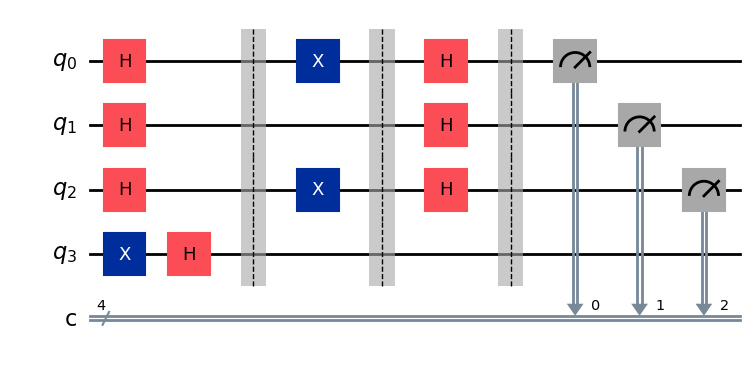

CircuitError: 'Index 0 out of range for size 0.'

In [52]:
# Run 

# Oracle type and input binary string
oracleType = 1
input_string = "000"

# Create the oracle and input circuits
oracle = createOracle(oracleType)



qc = QuantumCircuit(4,4)  # defining this circuit to stitch the classical bits
qc.h(0)
qc.h(1)
qc.h(2)
qc.x(3)
qc.h(3) 

qc.barrier()

qc = qc.compose(oracle)
qc.barrier()
qc.h(0)
qc.h(1)
qc.h(2)

qc.barrier()
qc.measure([0, 1, 2], [0, 1, 2])
display(qc.draw('mpl'))

# check if oracle is balanced or constant. 
# Runs the circuit 100 times. if the measurements are all 0 strings it is constant. otherwise if even one 1 present it is balanced. 


main_oracle.measure(0,0)
result = AerSimulator().run(main_oracle, shots=1, memory=True).result()
measurements = result.get_memory()
counts = result.get_counts()

# Extract counts for only the first 3 qubits
# trimmed_counts = {}
# for outcome, count in counts.items():
#     # Keep only the first 3 qubits (rightmost bits in Qiskit's convention)
#     first_3_qubits = outcome[-1:]  # Qiskit uses little-endian ordering
#     if first_3_qubits not in trimmed_counts:
#         trimmed_counts[first_3_qubits] = 0
#     trimmed_counts[first_3_qubits] += count


if "1" in measurements[0]:
    print("balanced")
else: 
    print("constant")

plot_histogram(counts)




# DJ algo tutorial copied

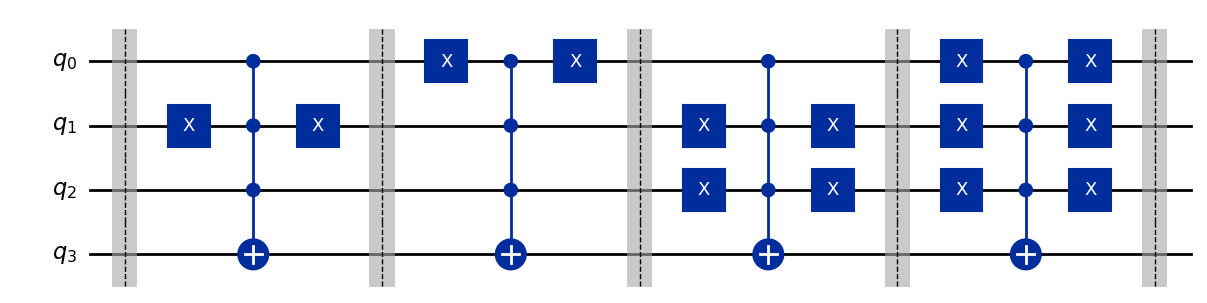

'balanced'

In [53]:
from qiskit import QuantumCircuit
import numpy as np

def dj_function(num_qubits):
    """
    Create a random Deutsch-Jozsa function.
    """

    qc = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 1):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 1):
        # return constant circuit with 50% chance
        return qc

    # next, choose half the possible input states
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created. They can safely be removed.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc


def compile_circuit(function: QuantumCircuit):
    """
    Compiles a circuit for use in the Deutsch-Jozsa algorithm.
    """
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


from qiskit_aer import AerSimulator

def dj_algorithm(function: QuantumCircuit):
    """
    Determine if a Deutsch-Jozsa function is constant or balanced.
    """
    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"



f = dj_function(3)

display(f.draw('mpl'))
display(dj_algorithm(f))



In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from itertools import product

# Define the function circuit (constant example: outputs always |0⟩)
n = 3  # Number of qubits
qc = QuantumCircuit(n, n)

# Example of a constant circuit: apply X to all qubits for |111⟩ output
qc.x(range(n))
qc.measure(range(n), range(n))
display(qc.draw('mpl'))
# Backend simulator

# Generate all possible inputs (2^n)
inputs = list(product([0, 1], repeat=n))
output_states = []

for input_state in inputs:
    # Create a new circuit for each input
    test_circuit = QuantumCircuit(n, n)
    
    # Prepare the input state
    for qubit, value in enumerate(input_state):
        if value == 1:
            test_circuit.x(qubit)  # Flip to |1> if input requires it
    
    # Append the test circuit to the original circuit
    test_circuit.compose(qc, inplace=True)
    
    # Execute the circuit
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    counts = result.get_counts()
    
    # Record the output state
    output_state = list(counts.keys())[0]  # Since shots=1, only one result
    output_states.append(output_state)

# Check if the outputs are constant
is_constant = all(state == output_states[0] for state in output_states)

print("Input States:", inputs)
print("Output States:", output_states)
print("Is the circuit constant?", is_constant)


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def deutsch_jozsa_3qubits(oracle):
    """Executes the Deutsch-Jozsa algorithm and determines if the function is constant or balanced."""
    
    qc = QuantumCircuit(4, 3)  # 3 input qubits + 1 auxiliary qubit, 3 classical bits for measurement

    # Step 1: Initialize qubits
    qc.x(3)  # Auxiliary qubit |1⟩
    
    # Step 2: Apply Hadamard transform
    qc.h(range(4))
    
    # Step 3: Apply the Oracle
    oracle(qc)
    display(oracle.draw('mpl'))
    # Step 4: Apply Hadamard transform again
    qc.h(range(3))

    # Step 5: Measure first 3 qubits
    qc.measure(range(3), range(3))

    # Run on AerSimulator
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()

    # Determine constant or balanced
    result_type = "BALANCED" if "1" in measurements[0] else "CONSTANT"
    
    return result_type, qc


def check_oracle_truth_table(oracle):
    """Runs the oracle alone, prints the truth table, and determines if it's balanced or constant."""
    truth_table = "Truth Table for Given Oracle:\n"
    truth_table += " x2 x1 x0 | f(x) \n"
    truth_table += "-----------------\n"
    
    results = []
    
    for x in range(8):  # Iterate over all 3-bit inputs (000 to 111)
        qc = QuantumCircuit(4, 1)  # 3 input qubits + 1 auxiliary, 1 classical bit
        
        # Initialize input state
        binary_x = format(x, "03b")  # Convert to binary string
        for i, bit in enumerate(reversed(binary_x)):
            if bit == "1":
                qc.x(i)  # Set the qubit to |1⟩

        # Apply Oracle
        oracle(qc)
        
        # Measure auxiliary qubit
        qc.measure(3,0)

        # Run the circuit
        simulator = AerSimulator()
        result = simulator.run(qc, shots=1, memory=True).result()
        output = result.get_memory()[0]  # Get measurement result
        
        truth_table += f" {binary_x}  |   {output} \n"
        results.append(int(output))  # Convert to int for checking

    truth_table += "-----------------\n"

    # Determine if function is constant or balanced
    if all(r == 0 for r in results) or all(r == 1 for r in results):
        oracle_type = "CONSTANT"
    else:
        oracle_type = "BALANCED"

    return truth_table, oracle_type


def run_deutsch_jozsa_with_oracle(oracle, oracle_name):
    """Runs Deutsch-Jozsa algorithm, prints oracle's truth table, and result in one output."""
    
    print(f"\n=== Running Deutsch-Jozsa Algorithm for {oracle_name} ===")
    
    # Run the Deutsch-Jozsa algorithm
    result_type, qc = deutsch_jozsa_3qubits(oracle)
    
    # Print the truth table of the oracle
    truth_table, oracle_type = check_oracle_truth_table(oracle)
    print(truth_table)
    
    # Print whether the oracle is balanced or constant
    print(f"Oracle Type (From Truth Table): {oracle_type}")
    
    # Print the result of the Deutsch-Jozsa algorithm
    print(f"Deutsch-Jozsa Result: {result_type}\n")
    display(qc.draw('mpl'))


# ===========================
# Oracle Implementations
# ===========================

def oracle_constant_0(qc):
    """Implements an oracle where f(x) = 0 for all x (does nothing)."""
    pass  # No gates needed

def oracle_constant_1(qc):
    """Implements an oracle where f(x) = 1 for all x (flips the auxiliary qubit)."""
    qc.x(3)  # Flip auxiliary qubit for all inputs

def oracle_balanced_1(qc):
    """Implements an oracle where f(x) = x0 (controlled-X on auxiliary qubit)."""
    qc.cx(0, 3)  # Control on qubit 0, flips auxiliary qubit if x0 = 1

def oracle_balanced_2(qc):
    """Implements an oracle where f(x) = x0 ⊕ x1 (controlled-X with two controls)."""
    qc.cx(0, 3)
    qc.cx(1, 3)  # Flip auxiliary qubit based on x0 XOR x1


# ===========================
# Run Tests with All Oracles
# ===========================

run_deutsch_jozsa_with_oracle(oracle_constant_0, "Constant Function f(x) = 0")
run_deutsch_jozsa_with_oracle(oracle_constant_1, "Constant Function f(x) = 1")
run_deutsch_jozsa_with_oracle(oracle_balanced_1, "Balanced Function f(x) = x0")
run_deutsch_jozsa_with_oracle(oracle_balanced_2, "Balanced Function f(x) = x0 ⊕ x1")


In [ ]:
def bv_function(s):
    """
    Create a Bernstein-Vazirani function from a string of 1s and 0s.
    """
    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc

display(bv_function("1001").draw())

q_0: ──■───────
       │       
q_1: ──┼───────
       │       
q_2: ──┼───────
       │       
q_3: ──┼────■──
     ┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├
     └───┘└───┘

In [55]:
def bv_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]

display(bv_algorithm(bv_function("1001")))

'1001'